# ☀️ Solar Power Forecasting — 1-Hour Ahead Prediction
**Model:** LightGBM  
**Target:** `target_solar_1h` — total AC power output 60 minutes ahead  
**Data sources:** InfluxDB (inverter telemetry + weather observations) · Open-Meteo Historical Forecast API

In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 1 — Imports and Connections
# ─────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import requests
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dotenv import load_dotenv
import os
import ssl
import certifi

from influxdb_client import InfluxDBClient
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

load_dotenv()
# 1. Create a clean SSL context using certifi's bundle
ssl_context = ssl.create_default_context(cafile=certifi.where())

# ── InfluxDB connection settings ──────────────────────────────
INFLUX_URL   = "https://influx.htetarkar.online"
INFLUX_TOKEN = os.getenv("influxdb_token")  # ← fill in your token
INFLUX_ORG   = "essco"
INFLUX_BUCKET = "essco_energy_data"

client    = InfluxDBClient(url=INFLUX_URL, token=INFLUX_TOKEN, org=INFLUX_ORG, ssl_context=ssl_context)
query_api = client.query_api()

print("✅ InfluxDB client initialised")
print(f"   URL : {INFLUX_URL}")
print(f"   Org : {INFLUX_ORG}")
print(f"   Bucket: {INFLUX_BUCKET}")

✅ InfluxDB client initialised
   URL : https://influx.htetarkar.online
   Org : essco
   Bucket: essco_energy_data


In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 2 — Query Inverter Data
# ─────────────────────────────────────────────────────────────

inverter_query = """
from(bucket: "essco_energy_data")
  |> range(start: -30d)
  |> filter(fn: (r) => r["_measurement"] == "inverter")
  |> filter(fn: (r) => r["siteId"] == "ESSCO_49453AB5")
  |> filter(fn: (r) =>
       r["_field"] == "ac_power_phase_a" or
       r["_field"] == "ac_power_phase_b" or
       r["_field"] == "ac_power_phase_c")
  |> pivot(rowKey: ["_time"], columnKey: ["_field"], valueColumn: "_value")
  |> keep(columns: ["_time", "ac_power_phase_a", "ac_power_phase_b", "ac_power_phase_c"])
"""

tables_inverter = query_api.query_data_frame(inverter_query)

# query_data_frame may return a list of DataFrames — concatenate if needed
if isinstance(tables_inverter, list):
    df_inverter = pd.concat(tables_inverter, ignore_index=True)
else:
    df_inverter = tables_inverter.copy()

# Rename the InfluxDB time column
df_inverter = df_inverter.rename(columns={"_time": "timestamp"})

# Keep only the columns we need
keep_cols = [c for c in ["timestamp", "ac_power_phase_a", "ac_power_phase_b", "ac_power_phase_c"] if c in df_inverter.columns]
df_inverter = df_inverter[keep_cols]

print(f"✅ Inverter data loaded  → shape: {df_inverter.shape}")
print(f"   Date range: {df_inverter['timestamp'].min()}  →  {df_inverter['timestamp'].max()}")
df_inverter

✅ Inverter data loaded  → shape: (1726, 4)
   Date range: 2026-05-29 05:49:35+00:00  →  2026-06-17 06:24:36+00:00


,timestamp,ac_power_phase_a,ac_power_phase_b,ac_power_phase_c
0,2026-05-29 05:49:35+00:00,708.90,711.60,705.30
1,2026-05-29 05:50:35+00:00,708.90,715.80,705.00
2,2026-05-29 05:51:35+00:00,638.01,643.95,634.50
3,2026-05-29 05:52:35+00:00,660.80,667.24,657.44
4,2026-05-29 05:53:35+00:00,708.90,715.50,705.00
...,...,...,...,...
1721,2026-06-17 06:20:36+00:00,2768.28,2749.20,2722.26
1722,2026-06-17 06:21:36+00:00,2486.76,2485.35,2466.35
1723,2026-06-17 06:22:36+00:00,2063.60,2058.42,2028.40
1724,2026-06-17 06:23:36+00:00,2227.75,2224.98,2190.69


In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 3 — Query Current Weather Data
# ─────────────────────────────────────────────────────────────

weather_query = """
from(bucket: "essco_energy_data")
  |> range(start: -30d)
  |> filter(fn: (r) => r["_measurement"] == "weather")
  |> filter(fn: (r) => r["siteId"] == "ESSCO")
  |> filter(fn: (r) =>
       r["_field"] == "solar_irradiance" or
       r["_field"] == "cloud_cover")
  |> pivot(rowKey: ["_time"], columnKey: ["_field"], valueColumn: "_value")
  |> keep(columns: ["_time", "solar_irradiance", "cloud_cover"])
"""

tables_weather = query_api.query_data_frame(weather_query)

if isinstance(tables_weather, list):
    df_weather = pd.concat(tables_weather, ignore_index=True)
else:
    df_weather = tables_weather.copy()

df_weather = df_weather.rename(columns={"_time": "timestamp"})

keep_cols = [c for c in ["timestamp", "solar_irradiance", "cloud_cover"] if c in df_weather.columns]
df_weather = df_weather[keep_cols]

print(f"✅ Weather data loaded  → shape: {df_weather.shape}")
print(f"   Date range: {df_weather['timestamp'].min()}  →  {df_weather['timestamp'].max()}")
df_weather.head(3)

✅ Weather data loaded  → shape: (244, 3)
   Date range: 2026-05-29 05:45:00+00:00  →  2026-06-17 06:20:39.075000+00:00


,timestamp,solar_irradiance,cloud_cover
0,2026-05-29 05:45:00+00:00,755.0,100.0
1,2026-05-29 06:00:00+00:00,733.0,100.0
2,2026-05-29 06:30:00+00:00,649.0,89.0


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 4 — Fetch Historical Forecast Data (Open-Meteo)
# ─────────────────────────────────────────────────────────────

# ── Site coordinates ──────────────────────────────────────────
LATITUDE  = 14.066094225657675    # ← update to your site latitude
LONGITUDE = 100.63597818535003   # ← update to your site longitude

# Build date range: last 30 days (UTC)
end_date   = pd.Timestamp.utcnow().normalize()
start_date = end_date - pd.Timedelta(days=30)

params = {
    "latitude"  : LATITUDE,
    "longitude" : LONGITUDE,
    "start_date": start_date.strftime("%Y-%m-%d"),
    "end_date"  : end_date.strftime("%Y-%m-%d"),
    "hourly"    : [
        "cloud_cover",
        "shortwave_radiation",
    ],
    "timezone"  : "UTC",
}

resp = requests.get(
    "https://historical-forecast-api.open-meteo.com/v1/forecast",
    params=params,
    timeout=60,
)
resp.raise_for_status()
json_data = resp.json()

# Parse hourly data
hourly = json_data["hourly"]
df_forecast = pd.DataFrame({
    "timestamp"                  : pd.to_datetime(hourly["time"]),
    "cloud_cover_forecast_1h"    : hourly["cloud_cover"],
    "solar_irradiance_forecast_1h": hourly["shortwave_radiation"],
})

# Ensure timestamps are UTC-aware
df_forecast["timestamp"] = df_forecast["timestamp"].dt.tz_localize("UTC")

print(f"✅ Open-Meteo forecast data fetched → shape: {df_forecast.shape}")
print(f"   Date range: {df_forecast['timestamp'].min()}  →  {df_forecast['timestamp'].max()}")
df_forecast

✅ Open-Meteo forecast data fetched → shape: (744, 3)
   Date range: 2026-05-19 00:00:00+00:00  →  2026-06-18 23:00:00+00:00


,timestamp,cloud_cover_forecast_1h,solar_irradiance_forecast_1h
0,2026-05-19 00:00:00+00:00,99,53.0
1,2026-05-19 01:00:00+00:00,98,218.0
2,2026-05-19 02:00:00+00:00,95,403.0
3,2026-05-19 03:00:00+00:00,98,573.0
4,2026-05-19 04:00:00+00:00,100,575.0
...,...,...,...
739,2026-06-18 19:00:00+00:00,100,0.0
740,2026-06-18 20:00:00+00:00,100,0.0
741,2026-06-18 21:00:00+00:00,98,0.0
742,2026-06-18 22:00:00+00:00,99,0.0


In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 5 — Resample All Sources to 5-Minute Grid
# ─────────────────────────────────────────────────────────────

def to_utc_index(df: pd.DataFrame, ts_col: str = "timestamp") -> pd.DataFrame:
    """Convert a timestamp column to a UTC-aware DatetimeIndex."""
    df = df.copy()
    df[ts_col] = pd.to_datetime(df[ts_col])
    if df[ts_col].dt.tz is None:
        df[ts_col] = df[ts_col].dt.tz_localize("UTC")
    else:
        df[ts_col] = df[ts_col].dt.tz_convert("UTC")
    df = df.set_index(ts_col).sort_index()
    return df


# ── 1. Inverter — 5-min mean ───────────────────────────────────
df_inverter = to_utc_index(df_inverter)
df_inverter = df_inverter.resample("5min").mean()  # limit=12 → max 1 hour gap interpolation
print(f"✅ df_inverter  resampled → {df_inverter.shape}")

# ── 2. Weather — 5-min mean + time interpolation ──────────────
df_weather = to_utc_index(df_weather)
df_weather = df_weather.resample("5min").mean().interpolate(method="time")
print(f"✅ df_weather   resampled → {df_weather.shape}")

# ── 3. Forecast — 5-min time interpolation (hourly → 5-min) ───
df_forecast = to_utc_index(df_forecast)
df_forecast = df_forecast.resample("5min").interpolate(method="time")
print(f"✅ df_forecast  resampled → {df_forecast.shape}")

print("\n📋 All sources aligned to 5-minute UTC grid")

✅ df_inverter  resampled → (5480, 3)
✅ df_weather   resampled → (5480, 2)
✅ df_forecast  resampled → (8917, 2)

📋 All sources aligned to 5-minute UTC grid


In [6]:
df_forecast.head(3)

,cloud_cover_forecast_1h,solar_irradiance_forecast_1h
timestamp,,
2026-05-19 00:00:00+00:00,99.000000,53.00
2026-05-19 00:05:00+00:00,98.916667,66.75
2026-05-19 00:10:00+00:00,98.833333,80.50


In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 6 — Create Total Solar Power (ac_power_total)
# ─────────────────────────────────────────────────────────────

df_inverter["ac_power_total"] = (
    df_inverter["ac_power_phase_a"]
    + df_inverter["ac_power_phase_b"]
    + df_inverter["ac_power_phase_c"]
)

# Drop rows where any phase is missing
# df_inverter = df_inverter.dropna(subset=["ac_power_phase_a", "ac_power_phase_b", "ac_power_phase_c"])

# Keep only the aggregate column
df_inverter = df_inverter[["ac_power_total"]]

df_inverter.shape

(5480, 1)

In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 7 — Join All Data Sources (Inner Join)
# ─────────────────────────────────────────────────────────────

# Inner join on the shared UTC DatetimeIndex
df = (
    df_inverter
    .join(df_weather,  how="inner")
    .join(df_forecast, how="inner")
)

print(f"✅ Joined dataset → shape: {df.shape}")
print(f"   Date range: {df.index.min()}  →  {df.index.max()}")
print(f"   Columns: {list(df.columns)}")
df.shape

✅ Joined dataset → shape: (5480, 5)
   Date range: 2026-05-29 05:45:00+00:00  →  2026-06-17 06:20:00+00:00
   Columns: ['ac_power_total', 'solar_irradiance', 'cloud_cover', 'cloud_cover_forecast_1h', 'solar_irradiance_forecast_1h']


(5480, 5)

df.shape   : (356, 5)

── dtypes ──────────────────────────────────
ac_power_total                  float64
solar_irradiance                float64
cloud_cover                     float64
cloud_cover_forecast_1h         float64
solar_irradiance_forecast_1h    float64
dtype: object

── describe ────────────────────────────────


,ac_power_total,solar_irradiance,cloud_cover,cloud_cover_forecast_1h,solar_irradiance_forecast_1h
count,356.000000,356.000000,356.000000,356.000000,356.000000
mean,4281.290686,414.841571,97.076139,90.254448,582.891854
std,2137.425857,176.689622,5.028742,10.582373,178.285521
min,0.000000,14.000000,74.000000,61.000000,48.000000
25%,2481.428500,295.000000,96.000000,87.062500,479.833333
50%,4316.161000,408.000000,100.000000,94.125000,590.625000
75%,5994.835250,559.333333,100.000000,98.666667,737.562500
max,8336.182000,808.666667,100.000000,100.000000,845.000000



── null counts ─────────────────────────────
ac_power_total                  0
solar_irradiance                0
cloud_cover                     0
cloud_cover_forecast_1h         0
solar_irradiance_forecast_1h    0
dtype: int64


KeyError: 'target_solar_1h'

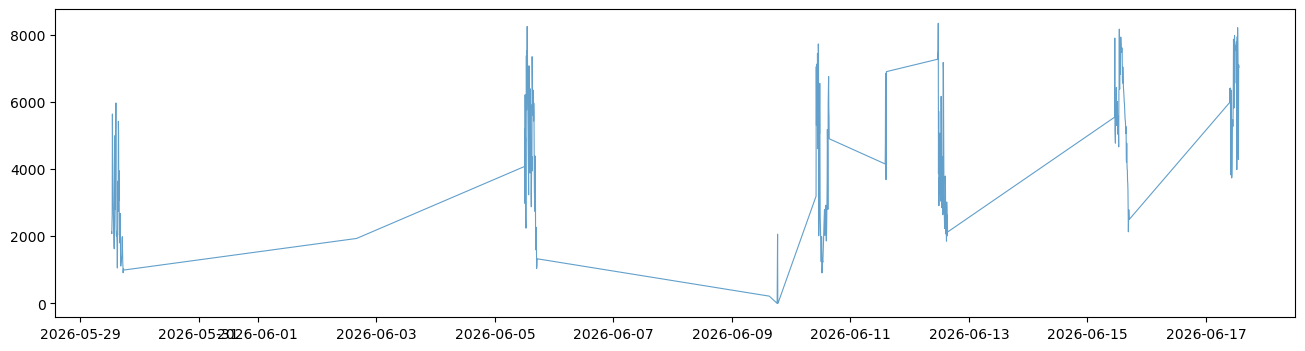

In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 13 — Exploratory Validation
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print(f"df.shape   : {df.shape}")
print("=" * 60)

print("\n── dtypes ──────────────────────────────────")
print(df.dtypes)

print("\n── describe ────────────────────────────────")
display(df.describe())

print("\n── null counts ─────────────────────────────")
print(df.isnull().sum())

# ── Plot ac_power_total vs target_solar_1h ────────────────────
fig, ax = plt.subplots(figsize=(16, 4))

# Convert to Bangkok time for the plot axis
local_ts = df.index.tz_convert("Asia/Bangkok")

ax.plot(local_ts, df["ac_power_total"],   label="ac_power_total (now)",    alpha=0.7, linewidth=0.8)
ax.plot(local_ts, df["target_solar_1h"],  label="target_solar_1h (+1 hr)", alpha=0.7, linewidth=0.8, linestyle="--")

ax.set_title("Solar AC Power — Current vs 1-Hour-Ahead Target", fontsize=14)
ax.set_xlabel("Timestamp (Asia/Bangkok)")
ax.set_ylabel("Power (W)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 14 — Train / Validation Split (Chronological)
# ─────────────────────────────────────────────────────────────

FEATURES = [
    # Current solar signal
    "ac_power_total",
    # Lag features
    "lag_1", "lag_2", "lag_3", "lag_4", "lag_6", "lag_12", "lag_288",
    # Rolling features
    "rolling_mean_6", "rolling_std_6", "rolling_mean_12", "rolling_mean_24",
    # Current weather observations
    "solar_irradiance", "cloud_cover",
    # Forecast weather
    "solar_irradiance_forecast_1h", "cloud_cover_forecast_1h",
    # Time features
    "hour_sin", "hour_cos", "day_of_week",
]

TARGET = "target_solar_1h"

# Chronological 80/20 split — no shuffling
split_idx = int(len(df) * 0.8)

df_train = df.iloc[:split_idx].copy()
df_val   = df.iloc[split_idx:].copy()

In [10]:
# TRAIN
df_train = df_train.interpolate(method="time")

# VALIDATION
df_val = df_val.ffill(limit=6)


print(df_train.isna().sum().sum())
print(df_val.isna().sum().sum())

0
973


In [12]:
print(len(df_val))
print(df_val["ac_power_total"].isna().sum())

1096
973


<Axes: xlabel='timestamp'>

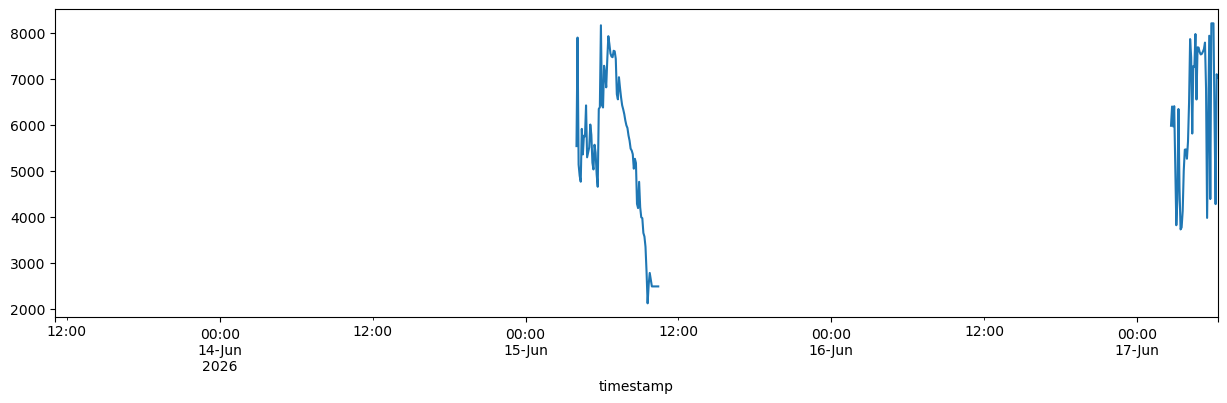

In [13]:
df_val["ac_power_total"].plot(figsize=(15,4))

In [ ]:
LAG_STEPS = [1, 2, 3, 4, 6, 12, 288]

for lag in LAG_STEPS:
    df_train[f"lag_{lag}"] = df_train["ac_power_total"].shift(lag)

df_train["rolling_mean_6"] = df_train["ac_power_total"].rolling(6).mean()
df_train["rolling_std_6"]  = df_train["ac_power_total"].rolling(6).std()
df_train["rolling_mean_12"] = df_train["ac_power_total"].rolling(12).mean()
df_train["rolling_mean_24"] = df_train["ac_power_total"].rolling(24).mean()

TARGET_SHIFT = 12
df_train["target_solar_1h"] = df_train["ac_power_total"].shift(-TARGET_SHIFT)

In [ ]:
for lag in LAG_STEPS:
    df_val[f"lag_{lag}"] = df_val["ac_power_total"].shift(lag)

df_val["rolling_mean_6"] = df_val["ac_power_total"].rolling(6).mean()
df_val["rolling_std_6"]  = df_val["ac_power_total"].rolling(6).std()
df_val["rolling_mean_12"] = df_val["ac_power_total"].rolling(12).mean()
df_val["rolling_mean_24"] = df_val["ac_power_total"].rolling(24).mean()

df_val["target_solar_1h"] = df_val["ac_power_total"].shift(-TARGET_SHIFT)

In [ ]:
df_train = df_train.dropna()
df_val = df_val.dropna()

In [ ]:
X_train = df_train[FEATURES]
y_train = df_train[TARGET]

X_val = df_val[FEATURES]
y_val = df_val[TARGET]

In [17]:
# ─────────────────────────────────────────────────────────────
# CELL 15 — Train LightGBM Model
# ─────────────────────────────────────────────────────────────

params = {
    "objective"    : "regression",
    "metric"       : "rmse",
    "learning_rate": 0.05,
    "num_leaves"   : 31,
    "n_estimators" : 500,
    "verbosity"    : -1,
    "random_state" : 42,
}

model = lgb.LGBMRegressor(**params)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=50),
    ],
)

print(f"\n✅ Training complete")
print(f"   Best iteration : {model.best_iteration_}")
print(f"   Best val RMSE  : {model.best_score_['valid_0']['rmse']:.2f} W")

Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 1490.92
Early stopping, best iteration is:
[49]	valid_0's rmse: 1487.36

✅ Training complete
   Best iteration : 49
   Best val RMSE  : 1487.36 W


  Validation Metrics (Solar Power)
  RMSE : 1,487.36 W
  MAE  : 1,297.02 W


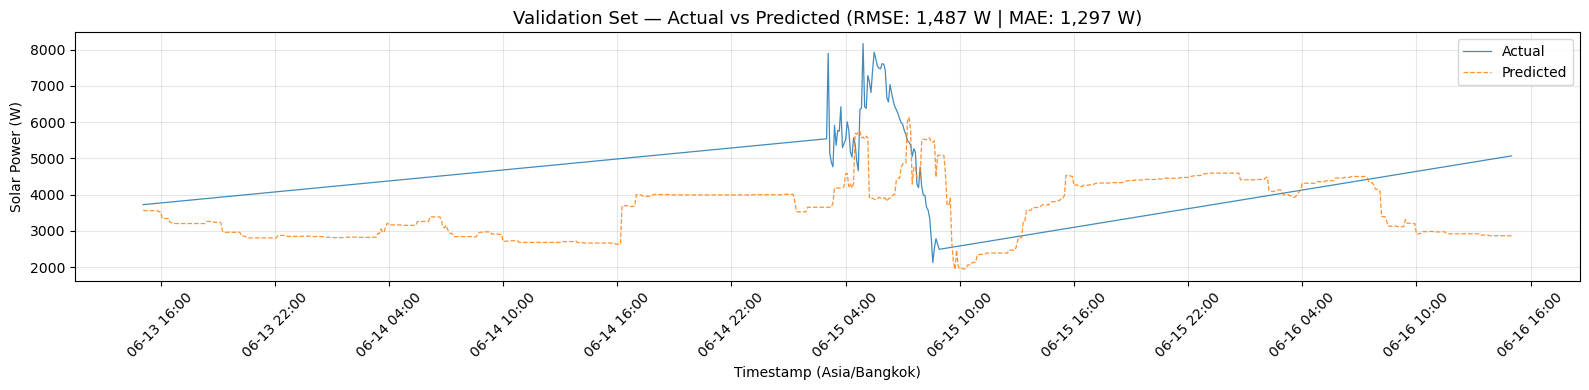

In [18]:
# ─────────────────────────────────────────────────────────────
# CELL 16 — Evaluate Model on Validation Set
# ─────────────────────────────────────────────────────────────

y_pred = model.predict(X_val)

rmse = root_mean_squared_error(y_val, y_pred)
mae  = mean_absolute_error(y_val, y_pred)

print("=" * 40)
print("  Validation Metrics (Solar Power)")
print("=" * 40)
print(f"  RMSE : {rmse:,.2f} W")
print(f"  MAE  : {mae:,.2f} W")
print("=" * 40)

# ── Actual vs Predicted plot ───────────────────────────────────
val_local_ts = df_val.index.tz_convert("Asia/Bangkok")
plot_n = min(len(df_val), 12 * 24 * 3)   # plot up to 3 days of 5-min data

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(val_local_ts[:plot_n], y_val.values[:plot_n],  label="Actual",    linewidth=0.9, alpha=0.85)
ax.plot(val_local_ts[:plot_n], y_pred[:plot_n],        label="Predicted", linewidth=0.9, alpha=0.85, linestyle="--")
ax.set_title(f"Validation Set — Actual vs Predicted (RMSE: {rmse:,.0f} W | MAE: {mae:,.0f} W)", fontsize=13)
ax.set_xlabel("Timestamp (Asia/Bangkok)")
ax.set_ylabel("Solar Power (W)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

   Validation Metrics (Solar Power)
   RMSE : 1,487.36 W
   MAE  : 1,297.02 W


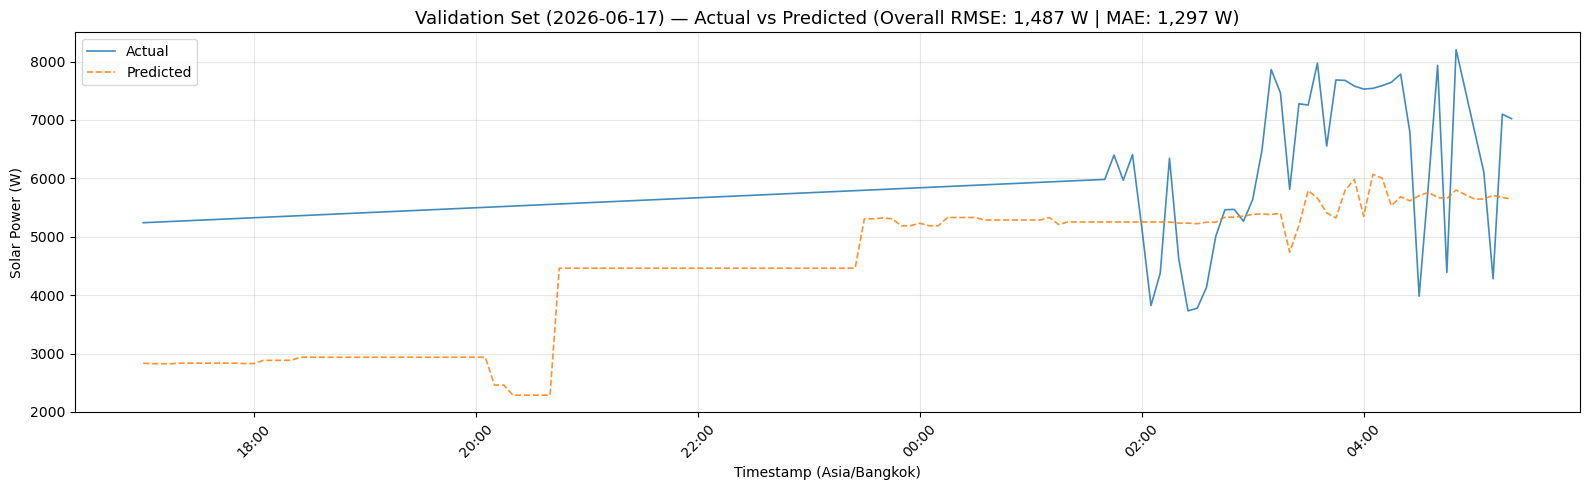

In [19]:
# ─────────────────────────────────────────────────────────────
# CELL 16 — Evaluate Model on Validation Set (Single Day)
# ─────────────────────────────────────────────────────────────

y_pred = model.predict(X_val)

# Calculate global validation metrics
rmse = root_mean_squared_error(y_val, y_pred)
mae  = mean_absolute_error(y_val, y_pred)

print("=" * 40)
print("   Validation Metrics (Solar Power)")
print("=" * 40)
print(f"   RMSE : {rmse:,.2f} W")
print(f"   MAE  : {mae:,.2f} W")
print("=" * 40)

# ── Filter for a single continuous day ───────────────────────
# Ensure index is localized to Bangkok for correct day slicing
val_local_ts = df_val.index.tz_convert("Asia/Bangkok")

# Choose a specific day present in your validation set
target_date = "2026-06-17"
day_mask = val_local_ts.normalize() == target_date

# Extract the continuous slices
ts_day = val_local_ts[day_mask]
y_val_day = y_val.values[day_mask]
y_pred_day = y_pred[day_mask]

# ── Actual vs Predicted plot ───────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(ts_day, y_val_day,  label="Actual",    linewidth=1.2, alpha=0.85)
ax.plot(ts_day, y_pred_day, label="Predicted", linewidth=1.2, alpha=0.85, linestyle="--")

ax.set_title(f"Validation Set ({target_date}) — Actual vs Predicted (Overall RMSE: {rmse:,.0f} W | MAE: {mae:,.0f} W)", fontsize=13)
ax.set_xlabel("Timestamp (Asia/Bangkok)")
ax.set_ylabel("Solar Power (W)")

# Tighter interval spacing since it's just one day
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))

plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# Sanity check — confirm split is still roughly 80/20 on final df
print(f"Train: {len(df_train)/len(df)*100:.1f}%  Val: {len(df_val)/len(df)*100:.1f}%")
assert len(df_val) > 0, "Validation set is empty — check CUTOFF_TIME"

Train: 80.0%  Val: 20.0%


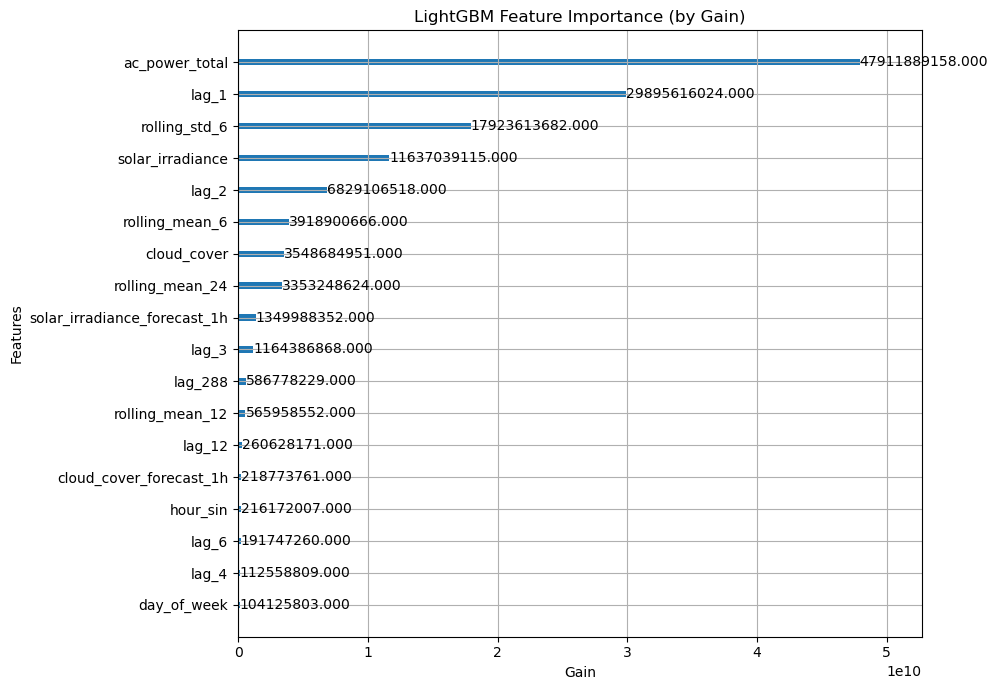


── Feature Importances (gain) ──────────────


,feature,importance
0,cloud_cover,201
1,solar_irradiance,159
2,ac_power_total,126
3,lag_288,108
4,rolling_std_6,100
5,solar_irradiance_forecast_1h,90
6,rolling_mean_24,77
7,rolling_mean_6,76
8,lag_1,74
9,hour_sin,71



💡 Interpretation tips:
   • High-importance lag/rolling features → strong auto-regression signal
   • High-importance irradiance/cloud features → weather is predictive
   • Low-importance features → candidates for removal in next iteration


In [21]:
# ─────────────────────────────────────────────────────────────
# CELL 17 — Feature Importance
# ─────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 7))
lgb.plot_importance(
    model,
    ax=ax,
    importance_type="gain",
    max_num_features=18,
    title="LightGBM Feature Importance (by Gain)",
    xlabel="Gain",
)
plt.tight_layout()
plt.show()

# ── Tabular view ───────────────────────────────────────────────
importance_df = pd.DataFrame({
    "feature"   : model.feature_name_,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("\n── Feature Importances (gain) ──────────────")
display(importance_df)

print("\n💡 Interpretation tips:")
print("   • High-importance lag/rolling features → strong auto-regression signal")
print("   • High-importance irradiance/cloud features → weather is predictive")
print("   • Low-importance features → candidates for removal in next iteration")